# Treated MonoCulture Simplified


## Step 1: Load treated monoculture day-averaged data


In [25]:
using Pkg

function ensure_pkgs(pkgs::Vector{String})
    deps = Pkg.dependencies()
    installed = Set([d.name for d in values(deps) if d.name !== nothing])
    missing = [p for p in pkgs if !(p in installed)]
    if !isempty(missing)
        Pkg.add(missing)
    end
end

# Keep this list aligned with symbols used in later cells.
# OrdinaryDiffEq provides ODE solvers; DelayDiffEq provides DDEProblem/MethodOfSteps.
pkgs = ["CSV", "DataFrames", "OrdinaryDiffEq", "DelayDiffEq", "Sundials", "Optim", "Plots", "Statistics"]
ensure_pkgs(pkgs)

using CSV, DataFrames, OrdinaryDiffEq, DelayDiffEq, Sundials, Optim, Plots, Statistics

In [26]:
# Resolve project root by walking up until Processed_Datasets is found
ROOT = pwd()
while !isdir(joinpath(ROOT, "Processed_Datasets")) && dirname(ROOT) != ROOT
    ROOT = dirname(ROOT)
end
@assert isdir(joinpath(ROOT, "Processed_Datasets")) "Could not locate project root from $(pwd())"

# Densities and doses
DENSITIES = ["20k", "30k"]
DOSE_ORDER = ["IC25", "IC50", "IC75"]
DOSE_VALS = Dict("IC25" => 1.47, "IC50" => 1.00, "IC75" => 0.62)
CELL_LINES = [:A2780Naive, :A2780cis]

# Base paths
TREATED_BASE = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture")
PARAM_FILE = joinpath(ROOT, "Modelling Data Notebooks", "Untreated MonoCulture", "untreated_monoculture_logistic_parameters.csv")
OUTPUT_DIR = joinpath(ROOT, "Modelling Data Notebooks", "Treated MonoCulture", "outputs")
mkpath(OUTPUT_DIR)

# Load day-averaged data and ensure day 0
function load_day_averages_with_day0(path::AbstractString; density::String)
    @assert isfile(path) "Missing file: $path"
    df = CSV.read(path, DataFrame)
    day_col    = findfirst(n -> String(n) == "Day", names(df))
    mean_col   = findfirst(n -> String(n) == "Mean Cells", names(df))
    stderr_col = findfirst(n -> String(n) == "SEM Cells", names(df))
    @assert day_col !== nothing && mean_col !== nothing "Missing required columns in $path. Available: $(names(df))"

    x    = Float64.(df[!, day_col])
    y    = Float64.(df[!, mean_col])
    yerr = stderr_col !== nothing ? Float64.(df[!, stderr_col]) : zeros(length(y))

    # Sort by day
    p = sortperm(x)
    x, y, yerr = x[p], y[p], yerr[p]

    # Insert day 0 if missing
    if minimum(x) > 0.1
        day0 = density == "20k" ? 67.0 : 100.0
        x    = vcat([0.0], x)
        y    = vcat([day0], y)
        yerr = vcat([0.0], yerr)
    else
        if x[1] == 0.0
            y[1] = density == "20k" ? 67.0 : 100.0
            yerr[1] = 0.0
        end
    end

    return x, y, yerr
end

# Find treated file for a given dose directory and cell line
function find_treated_file(dose_dir::AbstractString, cell_line::Symbol)
    name_sub = lowercase(String(cell_line))
    files = filter(f -> endswith(f, ".csv") && occursin("day_averages", lowercase(f)) && occursin(name_sub, lowercase(f)),
                   readdir(dose_dir; join=true))
    @assert !isempty(files) "No day_averages CSV for $cell_line in $dose_dir"
    return files[1]
end

# Load baseline parameters by density
function load_baseline_parameters(file::AbstractString)
    @assert isfile(file) "Missing baseline file: $file"
    df = CSV.read(file, DataFrame)
    required = [:CellLine, :Density, :r, :K, :v, :BIC]
    missing_cols = setdiff(required, Symbol.(names(df)))
    @assert isempty(missing_cols) "Missing columns: $(missing_cols)"

    # keep lowest BIC per (Density, CellLine)
    params = Dict{Tuple{String,Symbol}, Tuple{Float64,Float64,Float64,Float64}}()
    for row in eachrow(df)
        key = (string(row.Density), Symbol(row.CellLine))
        val = (Float64(row.r), Float64(row.K), Float64(row.v), Float64(row.BIC))
        if !haskey(params, key) || val[4] < params[key][4]
            params[key] = val
        end
    end

    return Dict(k => (v[1], v[2], v[3]) for (k, v) in params)
end

BASELINE_PARAMS = load_baseline_parameters(PARAM_FILE)


Dict{Tuple{String, Symbol}, Tuple{Float64, Float64, Float64}} with 4 entries:
  ("30k", :A2780Naive) => (1.05452, 4035.57, 0.574839)
  ("20k", :A2780Naive) => (1.13666, 4077.24, 0.624115)
  ("30k", :A2780cis)   => (0.46525, 3840.31, 3.28749)
  ("20k", :A2780cis)   => (0.494429, 3744.54, 3.95102)

## Step 2: Define model library (append-only)


In [27]:
epsu(x) = max(x, 1e-9)

# Model definition struct
struct DoseResponseModel
    name::String
    pnames::Vector{Symbol}
    lower::Vector{Float64}
    upper::Vector{Float64}
    simulate::Function   # (t_pts, p, dose, r, K, v, y0) -> y_pred
end

const MODEL_LIBRARY = Dict{String, DoseResponseModel}()

function add_model!(model::DoseResponseModel)
    if haskey(MODEL_LIBRARY, model.name)
        @warn "Model already exists, keeping original" model.name
        return
    end
    MODEL_LIBRARY[model.name] = model
end

# Helpers
hill_effect(dose, emax, n, ic50) = emax * (dose^n) / (ic50^n + dose^n + 1e-12)
hill_rate(dose, kmax, n, k50) = kmax * (dose^n) / (k50^n + dose^n + 1e-12)
growth_theta(N, r, K, θ) = r * N * (1 - (N / K)^θ)

# -------------------------
# Existing PARPi-style models (kept for continuity)
# -------------------------
model1_parpi = DoseResponseModel(
    "Model1_parpi",
    [:alpha, :beta, :d],
    [0.0, 0.0, 0.0],
    [1.0, 0.5, 4.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        alpha, beta, d = p
        alpha_eff = alpha
        function f!(du, u, p_, t)
            P, A = u
            N = P + A
            g = r * (1 - (N / K)^v)
            du[1] = g * (1 - 2*alpha_eff) * P + beta * A
            du[2] = alpha_eff * g * P - beta * A - d * A
        end
        u0 = [y0, 0.0]
        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1] + u[2], sol.u)
    end
)

const M2_NCOMP = 3
model2_parpi = DoseResponseModel(
    "Model2_parpi",
    [:alpha, :beta, :d],
    [0.0, 0.0, 0.0],
    [1.0, 0.5, 4.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        alpha, beta, d = p
        alpha_eff = alpha
        n = M2_NCOMP
        function f!(du, u, p_, t)
            P = u[1:n+1]
            A = u[n+2]
            N = sum(P) + A
            g = r * (1 - (N / K)^v)
            fill!(du, 0.0)
            du[1] = g*(1 - 2*alpha_eff)*P[1] + beta * P[2]
            for i in 2:n
                Pi_minus = P[i-1]
                Pi       = P[i]
                Pi_plus  = P[i+1]
                du[i] = 2*alpha_eff*g*Pi_minus + g*(1 - 2*alpha_eff)*Pi - beta*Pi + beta*Pi_plus
            end
            Pnm1 = P[n]
            Pn   = P[n+1]
            du[n+1] = 2*alpha_eff*g*Pnm1 + g*(1 - 2*alpha_eff)*Pn - beta*Pn + beta*A
            du[n+2] = alpha_eff*g*Pn - beta*A - d*A
        end
        u0 = zeros(n+2)
        u0[1] = y0
        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> sum(u[1:n+1]) + u[n+2], sol.u)
    end
)

model3_parpi = DoseResponseModel(
    "Model3_parpi",
    [:alpha, :beta, :gamma, :d],
    [0.0, 0.0, 0.0, 0.0],
    [1.0, 0.5, 4.0, 4.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        alpha, beta, gamma, d = p
        alpha_eff = alpha
        function f!(du, u, p_, t)
            P, Pd, A = u
            N = P + Pd + A
            g = r * (1 - (N / K)^v)
            du[1] = g*(1 - 2*alpha_eff)*P + beta*Pd
            du[2] = 2*alpha_eff*g*P + g*Pd - gamma*Pd - beta*Pd + beta*A
            du[3] = gamma*Pd - beta*A - d*A
        end
        u0 = [y0, 0.0, 0.0]
        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1] + u[2] + u[3], sol.u)
    end
)

model4_parpi = DoseResponseModel(
    "Model4_parpi",
    [:alpha, :phi, :d],
    [0.0, 0.0, 0.0],
    [1.0, 2.0, 4.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        alpha, phi, d = p
        alpha_eff = alpha
        function f!(du, u, p_, t)
            P, A = u
            N = P + A
            g = r * (1 - (N / K)^v)
            du[1] = g*(1 - 2*alpha_eff)*P
            du[2] = (1 + phi)*alpha_eff*g*P - d*A
        end
        u0 = [y0, 0.0]
        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1] + u[2], sol.u)
    end
)

model_time_delay = DoseResponseModel(
    "time_delay",
    [:alpha, :beta, :n, :kD],
    [0.0, 0.0, 0.5, 1e-3],
    [1.0, 0.5, 6.0, 100.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        alpha, beta, n, kD = p
        D = (dose^n) / (kD^n + dose^n + 1e-12)
        function f!(du, u, p_, t)
            S = epsu(u[1])
            alpha_t = alpha * (1 + beta * t)
            g = r * S * (1 - (S / K)^v)
            du[1] = g * (1 - 2 * alpha_t * D)
        end
        u0 = [y0]
        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        getindex.(sol.u, 1)
    end
)

# -------------------------
# Added core treated-growth model zoo
# -------------------------

# 1) Single-population theta-logistic × Hill inhibition
model_theta_hill_inhibition = DoseResponseModel(
    "theta_hill_inhibition",
    [:Emax, :n, :IC50],
    [0.0, 0.5, 1e-3],
    [1.0, 6.0, 100.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        Emax, n, IC50 = p
        E = hill_effect(dose, Emax, n, IC50)
        function f!(du, u, p_, t)
            N = epsu(u[1])
            du[1] = growth_theta(N, r, K, v) * (1 - E)
        end
        prob = ODEProblem(f!, [y0], (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        getindex.(sol.u, 1)
    end
)

# 2) Growth + Hill kill
model_theta_hill_kill = DoseResponseModel(
    "theta_hill_kill",
    [:kmax, :n, :K50],
    [0.0, 0.5, 1e-3],
    [4.0, 6.0, 100.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        kmax, n, K50 = p
        kD = hill_rate(dose, kmax, n, K50)
        function f!(du, u, p_, t)
            N = epsu(u[1])
            du[1] = growth_theta(N, r, K, v) - kD * N
        end
        prob = ODEProblem(f!, [y0], (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        getindex.(sol.u, 1)
    end
)

# 3) DDE delayed inhibition
model_theta_hill_inhibition_dde = DoseResponseModel(
    "theta_hill_inhibition_dde",
    [:Emax, :n, :IC50, :tau],
    [0.0, 0.5, 1e-3, 0.0],
    [1.0, 6.0, 100.0, 6.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        Emax, n, IC50, tau = p
        h(p_, t) = [y0]
        function f!(du, u, hfun, p_, t)
            Nτ = epsu(hfun(p_, t - tau)[1])
            Eτ = hill_effect(dose, Emax, n, IC50)
            N = epsu(u[1])
            du[1] = growth_theta(N, r, K, v) * (1 - Eτ)
        end
        prob = DDEProblem(f!, [y0], h, (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob, MethodOfSteps(Tsit5()); saveat=t_pts, reltol=1e-6, abstol=1e-8)
        getindex.(sol.u, 1)
    end
)

# 3) DDE delayed kill
model_theta_hill_kill_dde = DoseResponseModel(
    "theta_hill_kill_dde",
    [:kmax, :n, :K50, :tau],
    [0.0, 0.5, 1e-3, 0.0],
    [4.0, 6.0, 100.0, 6.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        kmax, n, K50, tau = p
        h(p_, t) = [y0]
        function f!(du, u, hfun, p_, t)
            Nτ = epsu(hfun(p_, t - tau)[1])
            kτ = hill_rate(dose, kmax, n, K50)
            N = epsu(u[1])
            du[1] = growth_theta(N, r, K, v) - kτ * Nτ
        end
        prob = DDEProblem(f!, [y0], h, (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob, MethodOfSteps(Tsit5()); saveat=t_pts, reltol=1e-6, abstol=1e-8)
        getindex.(sol.u, 1)
    end
)

# 4) Lag-phase growth ramp + Hill inhibition
model_lag_hill_inhibition = DoseResponseModel(
    "lag_hill_inhibition",
    [:Emax, :n, :IC50, :t_lag, :m],
    [0.0, 0.5, 1e-3, 0.01, 0.5],
    [1.0, 6.0, 100.0, 8.0, 8.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        Emax, n, IC50, t_lag, m = p
        E = hill_effect(dose, Emax, n, IC50)
        function g(t)
            return t <= 0 ? 0.0 : (t^m) / (t^m + t_lag^m + 1e-12)
        end
        function f!(du, u, p_, t)
            N = epsu(u[1])
            du[1] = growth_theta(N, r, K, v) * g(t) * (1 - E)
        end
        prob = ODEProblem(f!, [y0], (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        getindex.(sol.u, 1)
    end
)

# 5) Bi-exponential response (phenomenological)
model_biexponential = DoseResponseModel(
    "biexponential",
    [:w, :lambda1, :lambda2],
    [0.0, 0.0, 0.0],
    [1.0, 4.0, 4.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        w, λ1, λ2 = p
        t0 = minimum(t_pts)
        [y0 * (w * exp(-λ1 * (t - t0)) + (1 - w) * exp(-λ2 * (t - t0))) for t in t_pts]
    end
)

# 6) Sensitive-Resistant model
model_sensitive_resistant = DoseResponseModel(
    "sensitive_resistant",
    [:rS_scale, :rR_scale, :kS_max, :kR_max, :n, :K50S, :K50R, :S0_frac],
    [0.2, 0.1, 0.0, 0.0, 0.5, 1e-3, 1e-3, 0.01],
    [2.0, 2.0, 4.0, 2.0, 6.0, 100.0, 100.0, 0.99],
    (t_pts, p, dose, r, K, v, y0) -> begin
        rS_scale, rR_scale, kS_max, kR_max, n, K50S, K50R, S0_frac = p
        kS = hill_rate(dose, kS_max, n, K50S)
        kR = hill_rate(dose, kR_max, n, K50R)
        S0 = y0 * S0_frac
        R0 = y0 * (1 - S0_frac)
        function f!(du, u, p_, t)
            S = epsu(u[1]); R = epsu(u[2]); N = S + R
            crowd = max(1 - (N / K)^v, -5.0)
            du[1] = (r * rS_scale) * S * crowd - kS * S
            du[2] = (r * rR_scale) * R * crowd - kR * R
        end
        prob = ODEProblem(f!, [S0, R0], (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1] + u[2], sol.u)
    end
)

# 7) Damage-repair-arrest model
model_damage_repair_arrest = DoseResponseModel(
    "damage_repair_arrest",
    [:kmax, :n, :K50, :k_rep, :k_arr, :dA],
    [0.0, 0.5, 1e-3, 0.0, 0.0, 0.0],
    [4.0, 6.0, 100.0, 2.0, 2.0, 2.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        kmax, n, K50, k_rep, k_arr, dA = p
        kdam = hill_rate(dose, kmax, n, K50)
        function f!(du, u, p_, t)
            S = epsu(u[1]); Dm = epsu(u[2]); A = epsu(u[3])
            N = S + Dm + A
            grow = r * S * (1 - (N / K)^v)
            du[1] = grow - kdam * S + k_rep * Dm
            du[2] = kdam * S - k_rep * Dm - k_arr * Dm
            du[3] = k_arr * Dm - dA * A
        end
        prob = ODEProblem(f!, [y0, 0.0, 0.0], (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1] + u[2] + u[3], sol.u)
    end
)

# 8) Transit chain / Erlang delay approximation (m fixed = 4)
const TRANSIT_M = 4
model_transit_erlang_m4 = DoseResponseModel(
    "transit_erlang_m4",
    [:kmax, :n, :K50, :tau],
    [0.0, 0.5, 1e-3, 0.2],
    [4.0, 6.0, 100.0, 10.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        kmax, n, K50, tau = p
        kdam = hill_rate(dose, kmax, n, K50)
        m = TRANSIT_M
        λ = m / max(tau, 1e-6)
        function f!(du, u, p_, t)
            S = epsu(u[1])
            X = u[2:end]
            N = S + sum(X)
            du[1] = r * S * (1 - (N / K)^v) - kdam * S
            du[2] = kdam * S - λ * X[1]
            for j in 2:m
                du[1 + j] = λ * X[j - 1] - λ * X[j]
            end
        end
        u0 = zeros(m + 1)
        u0[1] = y0
        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> sum(u), sol.u)
    end
)

# 9) Adaptive resistance via dynamic IC50(t)
model_adaptive_ic50 = DoseResponseModel(
    "adaptive_ic50",
    [:Emax, :n, :IC50_0, :a, :b],
    [0.0, 0.5, 1e-3, 0.0, 0.0],
    [1.0, 6.0, 100.0, 2.0, 2.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        Emax, n, IC50_0, a, b = p
        function f!(du, u, p_, t)
            N = epsu(u[1])
            IC50t = epsu(u[2])
            E = hill_effect(dose, Emax, n, IC50t)
            du[1] = growth_theta(N, r, K, v) * (1 - E)
            du[2] = a * dose - b * (IC50t - IC50_0)
        end
        prob = ODEProblem(f!, [y0, IC50_0], (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1], sol.u)
    end
)

# 10) PK-PD coupled model (constant initial dose, no further input)
model_pkpd_hill_inhibition = DoseResponseModel(
    "pkpd_hill_inhibition",
    [:Emax, :n, :IC50, :k_e],
    [0.0, 0.5, 1e-3, 0.0],
    [1.0, 6.0, 100.0, 2.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        Emax, n, IC50, k_e = p
        function f!(du, u, p_, t)
            N = epsu(u[1])
            C = max(u[2], 0.0)
            E = hill_effect(C, Emax, n, IC50)
            du[1] = growth_theta(N, r, K, v) * (1 - E)
            du[2] = -k_e * C
        end
        prob = ODEProblem(f!, [y0, dose], (minimum(t_pts), maximum(t_pts)))
        sol = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1], sol.u)
    end
)

# Register all models
add_model!(model1_parpi)
add_model!(model2_parpi)
add_model!(model3_parpi)
add_model!(model4_parpi)
add_model!(model_time_delay)

add_model!(model_theta_hill_inhibition)
add_model!(model_theta_hill_kill)
add_model!(model_theta_hill_inhibition_dde)
add_model!(model_theta_hill_kill_dde)
add_model!(model_lag_hill_inhibition)
add_model!(model_biexponential)
add_model!(model_sensitive_resistant)
add_model!(model_damage_repair_arrest)
add_model!(model_transit_erlang_m4)
add_model!(model_adaptive_ic50)
add_model!(model_pkpd_hill_inhibition)


DoseResponseModel("pkpd_hill_inhibition", [:Emax, :n, :IC50, :k_e], [0.0, 0.5, 0.001, 0.0], [1.0, 6.0, 100.0, 2.0], var"#331#333"())

## Step 3: Run fits + BIC comparison


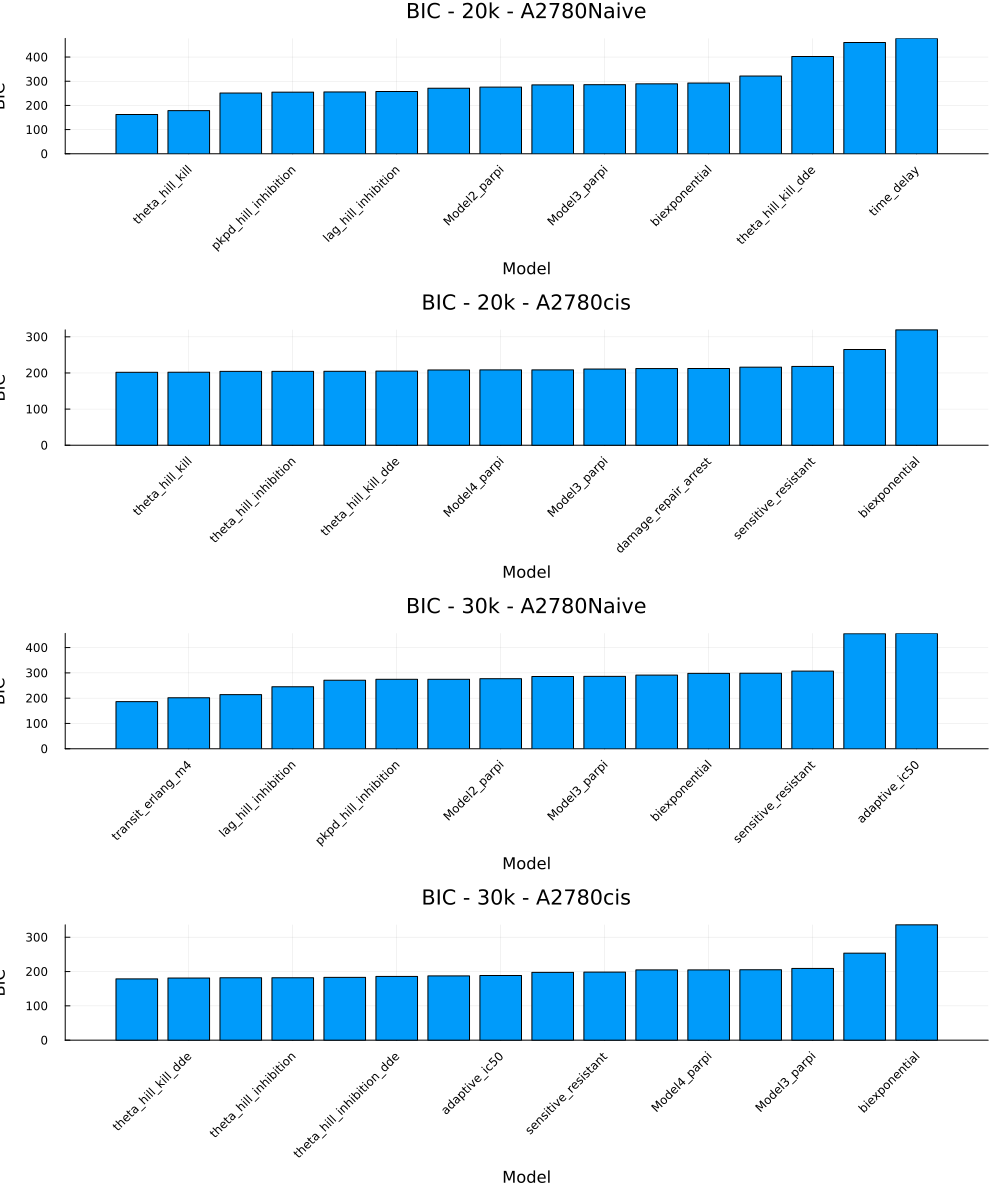

Saved results to:
  c:\Users\elbak\OneDrive\Desktop\3_Research\CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\outputs\treated_monoculture_model_bic_results.csv
  c:\Users\elbak\OneDrive\Desktop\3_Research\CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\outputs\treated_monoculture_best_models.csv


In [28]:
# Ensure required packages are loaded in this cell's execution context
using Optim, DataFrames, CSV, Plots, OrdinaryDiffEq, DelayDiffEq

# Fit shared drug parameters across IC25/IC50/IC75 for each density + cell line

function params_to_str(names, values)
    return join(["$(String(n))=$(round(v, digits=4))" for (n, v) in zip(names, values)], ", ")
end

function dataset_sse(model::DoseResponseModel, p, dataset, r, K, v; fixed_ic50=nothing)
    p_use = collect(p)
    if fixed_ic50 !== nothing
        idx = findfirst(isequal(:IC50), model.pnames)
        if idx !== nothing
            p_use[idx] = fixed_ic50
        end
    end
    y_pred = try
        model.simulate(dataset.x, p_use, dataset.dose_val, r, K, v, dataset.y0)
    catch
        return Inf
    end
    if length(y_pred) != length(dataset.y)
        return Inf
    end
    w = dataset.yerr === nothing ? ones(length(dataset.y)) :
        1.0 ./ (Float64.(dataset.yerr).^2 .+ 1e-12)
    return sum(w .* (y_pred .- Float64.(dataset.y)).^2)
end

function fit_shared_across_doses(model::DoseResponseModel, datasets, r, K, v; n_starts::Int=8, fixed_ic50=nothing)
    kpar = length(model.pnames)
    n_obs_total = sum(length(d.y) for d in datasets)
    idx_ic50 = findfirst(isequal(:IC50), model.pnames)

    function loss(p)
        p_clamped = clamp.(p, model.lower, model.upper)
        if fixed_ic50 !== nothing && idx_ic50 !== nothing
            p_clamped = collect(p_clamped)
            p_clamped[idx_ic50] = fixed_ic50
        end
        total = 0.0
        for d in datasets
            w_sse = dataset_sse(model, p_clamped, d, r, K, v; fixed_ic50=fixed_ic50)
            if !isfinite(w_sse)
                return 1e12
            end
            total += w_sse
        end
        return total
    end

    best_p = nothing
    best_val = Inf

    for s in 1:n_starts
        init = [rand() * (hi - lo) + lo for (lo, hi) in zip(model.lower, model.upper)]
        res = Optim.optimize(
            loss, model.lower, model.upper, init,
            Fminbox(NelderMead()),
            Optim.Options(iterations=400, show_trace=false)
        )
        val = Optim.minimum(res)
        if val < best_val
            best_val = val
            best_p = Optim.minimizer(res)
        end
    end

    p_opt = best_p
    if fixed_ic50 !== nothing && idx_ic50 !== nothing
        p_opt = collect(p_opt)
        p_opt[idx_ic50] = fixed_ic50
    end
    sse = best_val
    s2  = sse / n_obs_total
    bic = n_obs_total * log(s2) + kpar * log(n_obs_total)
    aic = n_obs_total * log(s2) + 2kpar

    return (model=model, p_opt=p_opt, sse=sse, bic=bic, aic=aic)
end

# Build datasets and fit
results_rows = DataFrame(
    density = String[],
    cell_line = String[],
    model = String[],
    title = String[],
    params = String[],
    sse = Float64[],
    bic = Float64[],
    aic = Float64[],
)

datasets_cache = Dict{Tuple{String,Symbol}, Vector{NamedTuple}}()

for dens in DENSITIES
    for cl in CELL_LINES
        key = (dens, cl)
        r, K, v = BASELINE_PARAMS[(dens, cl)]

        datasets = NamedTuple{(:dose_name,:dose_val,:x,:y,:yerr,:y0)}[]
        for dn in DOSE_ORDER
            dose_dir = joinpath(TREATED_BASE, dens, dn, "Averages")
            data_path = find_treated_file(dose_dir, cl)
            x, y, yerr = load_day_averages_with_day0(data_path; density=dens)
            push!(datasets, (
                dose_name = dn,
                dose_val  = DOSE_VALS[dn],
                x         = x,
                y         = y,
                yerr      = yerr,
                y0        = y[1],
            ))
        end
        datasets_cache[key] = datasets

        fixed_ic50 = cl == :A2780Naive ? 1.0 : nothing

        for (name, model) in MODEL_LIBRARY
            res = fit_shared_across_doses(model, datasets, r, K, v; fixed_ic50=fixed_ic50)
            push!(results_rows, (
                dens,
                String(cl),
                name,
                name,
                params_to_str(model.pnames, res.p_opt),
                res.sse,
                res.bic,
                res.aic
            ))
        end
    end
end

results_csv = joinpath(OUTPUT_DIR, "treated_monoculture_model_bic_results.csv")
CSV.write(results_csv, results_rows)

# Best model per density + cell line
best_rows = combine(groupby(results_rows, [:density, :cell_line])) do sdf
    sdf[argmin(sdf.bic), :]
end

best_csv = joinpath(OUTPUT_DIR, "treated_monoculture_best_models.csv")
CSV.write(best_csv, best_rows)

println("Saved results to:")
println("  ", results_csv)
println("  ", best_csv)

# BIC bar plots per density + cell line
function plot_bic_bars(df::DataFrame)
    plots = Any[]
    for dens in unique(df.density)
        for cl in unique(df.cell_line)
            sub = sort(df[(df.density .== dens) .& (df.cell_line .== cl), :], :bic)
            p = bar(sub.model, sub.bic; title="BIC - $(dens) - $(cl)", legend=false, xrotation=45, xlabel="Model", ylabel="BIC")
            push!(plots, p)
        end
    end
    display(plot(plots...; layout=(length(plots), 1), size=(1000, 300 * length(plots))))
end

plot_bic_bars(results_rows)


## Step 4: Plot best model fits (per density)


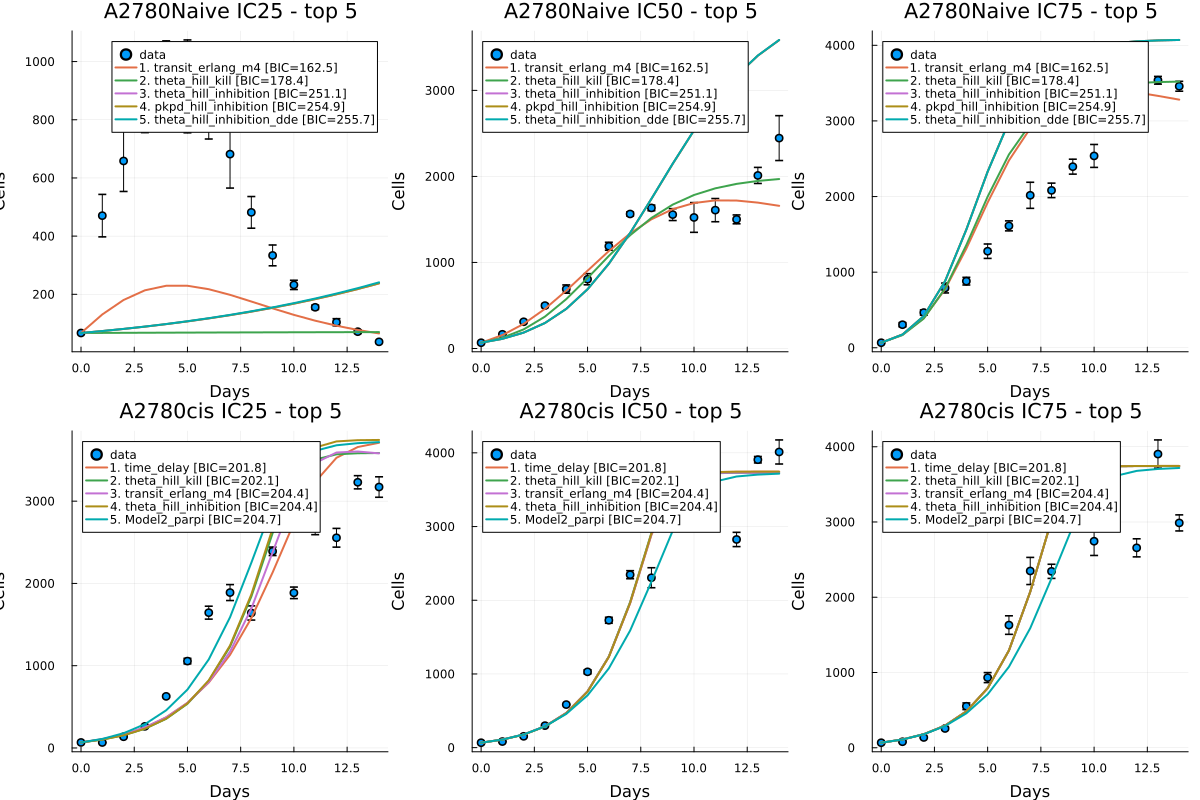

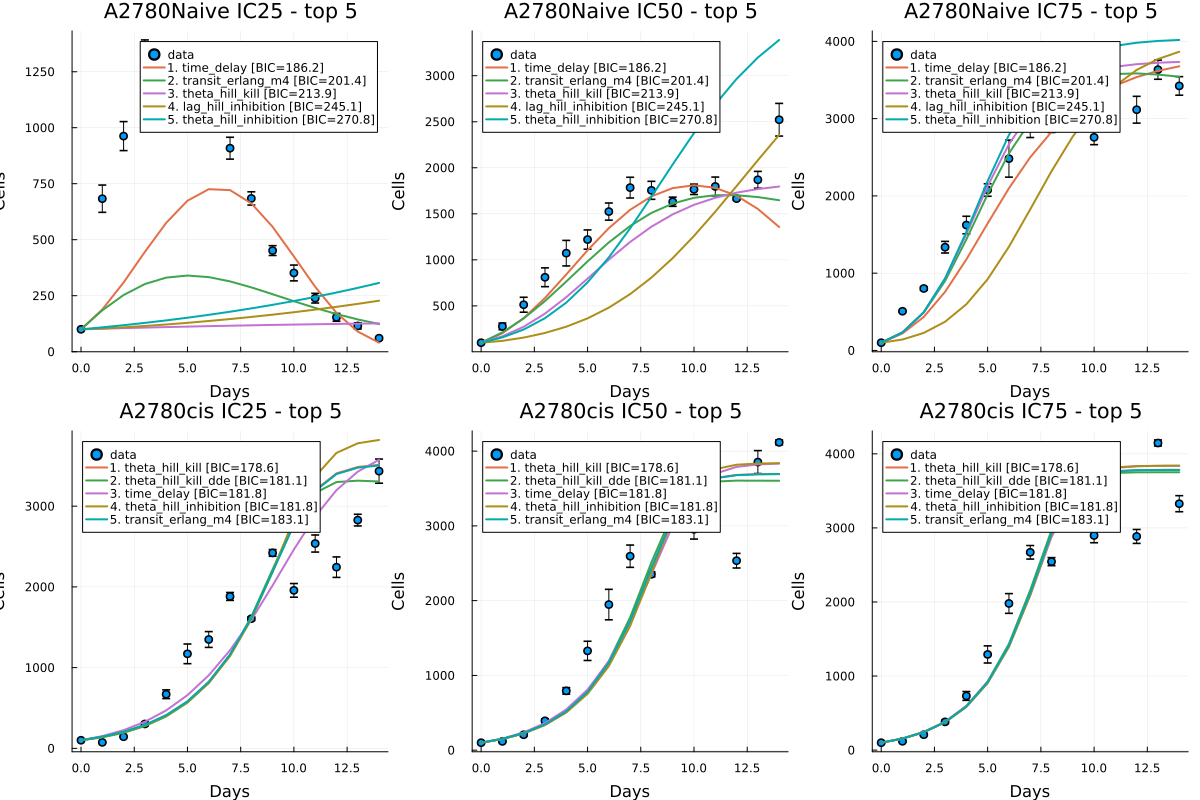

Saved grid: c:\Users\elbak\OneDrive\Desktop\3_Research\CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\outputs\treated_monoculture_top5_grid_20k.png
Saved grid: c:\Users\elbak\OneDrive\Desktop\3_Research\CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\outputs\treated_monoculture_top5_grid_30k.png


In [29]:
# Ensure required packages are loaded in this cell's execution context
using CSV, DataFrames, Plots, OrdinaryDiffEq, DelayDiffEq

# Plot grids for each density: 2 (cell lines) x 3 (doses), with top-N model fits

function parse_params(s::AbstractString)
    parts = split(s, ',')
    vals = Float64[]
    for p in parts
        v = split(p, "=")[end]
        push!(vals, parse(Float64, strip(v)))
    end
    return vals
end

function load_datasets_for(dens::String, cl::Symbol)
    datasets = NamedTuple{(:dose_name,:dose_val,:x,:y,:yerr,:y0)}[]
    for dn in DOSE_ORDER
        dose_dir = joinpath(TREATED_BASE, dens, dn, "Averages")
        data_path = find_treated_file(dose_dir, cl)
        x, y, yerr = load_day_averages_with_day0(data_path; density=dens)
        push!(datasets, (
            dose_name = dn,
            dose_val  = DOSE_VALS[dn],
            x         = x,
            y         = y,
            yerr      = yerr,
            y0        = y[1],
        ))
    end
    return datasets
end

function top_n_rows_for_density_cell(dens::String, cl_str::String; n_best::Int=5)
    all_df = CSV.read(joinpath(OUTPUT_DIR, "treated_monoculture_model_bic_results.csv"), DataFrame)
    sub = all_df[(all_df.density .== dens) .& (all_df.cell_line .== cl_str), :]
    @assert nrow(sub) > 0 "No model rows found for density=$(dens), cell_line=$(cl_str)"
    sub = sort(sub, :bic)
    return sub[1:min(n_best, nrow(sub)), :]
end

function plot_best_grid_for_density(dens::String; n_best::Int=5)
    plt = plot(layout=(2, 3), size=(1200, 800))

    for (i_cl, cl_str) in enumerate(string.(CELL_LINES))
        cl_sym = Symbol(cl_str)
        r, K, v = BASELINE_PARAMS[(dens, cl_sym)]

        top_rows = top_n_rows_for_density_cell(dens, cl_str; n_best=n_best)
        model_entries = NamedTuple{(:name,:params,:bic)}[]
        for row in eachrow(top_rows)
            model_name = String(row.model)
            if haskey(MODEL_LIBRARY, model_name)
                push!(model_entries, (
                    name   = model_name,
                    params = parse_params(String(row.params)),
                    bic    = Float64(row.bic),
                ))
            end
        end
        @assert !isempty(model_entries) "No plottable models found for density=$(dens), cell_line=$(cl_str)"

        datasets = load_datasets_for(dens, cl_sym)
        for (j_dn, dn) in enumerate(DOSE_ORDER)
            idx = (i_cl - 1) * 3 + j_dn
            d = filter(dd -> dd.dose_name == dn, datasets)[1]

            plot!(plt[idx], d.x, d.y; yerror=d.yerr, seriestype=:scatter, label="data", title="$(cl_str) $(dn) - top $(n_best)")

            for (k, entry) in enumerate(model_entries)
                y_pred = MODEL_LIBRARY[entry.name].simulate(d.x, entry.params, d.dose_val, r, K, v, d.y0)
                lbl = "$(k). $(entry.name) [BIC=$(round(entry.bic, digits=1))]"
                plot!(plt[idx], d.x, y_pred; label=lbl, lw=2)
            end

            xlabel!(plt[idx], "Days")
            ylabel!(plt[idx], "Cells")
        end
    end

    display(plt)
    out_path = joinpath(OUTPUT_DIR, "treated_monoculture_top$(n_best)_grid_$(dens).png")
    savefig(plt, out_path)
    println("Saved grid: ", out_path)
end

plot_best_grid_for_density("20k"; n_best=5)
plot_best_grid_for_density("30k"; n_best=5)
